# chrisMain — VarMeanNoise Analysis

Goal: pull stimulus + response data for the `varMeanNoise` protocol, then transfer cell types and STAs from the nearest noise (`SpatialNoise`) chunk via EI matching.

Steps:
1. Find every experiment that ran `varMeanNoise`
2. Pick a date
3. Build the pipeline (StimBlock + ResponseBlock for the protocol, AnalysisChunk for the noise chunk; `create_mea_pipeline` runs the EI-based cluster match automatically)
4. Sanity-check the matching by comparing RFs
5. Pull spike trains as an xarray for downstream analysis

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

/Users/chrischen/opt/anaconda3/envs/retinanalysis/lib/python3.11/site-packages/datajoint/settings.py:979: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


[2026-05-12 18:18:04] DataJoint 2.1.1 connected to root@127.0.0.1:3306


## 1. Find all experiments that ran `varMeanNoise`

`get_datasets_from_protocol_names` does a lowercase substring match against the protocol registry, so `'varmeannoise'` will catch the full Java class name (e.g. `manookinlab.protocols.VarMeanNoise`). After the DB query we filter to only experiments whose sort output is actually present on disk (`ra.ANALYSIS_DIR`).

In [2]:
exp_search = ra.get_datasets_from_protocol_names('AlternatingBackground')

# Filter to experiments that exist on the MEA SSD
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop=True)

print(f'{len(exp_search)} usable datafile(s) found across '
      f'{exp_search.exp_name.nunique()} experiment(s).')
display(exp_search)


Found 1 protocols matching "alternatingbackground":
['edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']



Found 23 experiments, 32 epoch blocks.

27 usable datafile(s) found across 18 experiment(s).


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20220823C,data035,NaN,chunk5,edu.washington.riekelab.turner.protocols.EyeMo...,1,20220823C/data035,Eye movement trajectory alt background rod,22,41,315,866,45
1,20221006C,data029,1.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221006C/data029,Eye movement trajectory alternating background,25,41,386,972,54
2,20221101C,data018,0.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data018,Eye movement alt background,27,41,440,1047,56
3,20221101C,data025,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data025,Eye movement alt background,27,41,442,1054,57
4,20221101C,data032,0.0,chunk3,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221101C/data032,Eye movement alt background,27,41,444,1061,57
5,20221123C,data027,2.0,chunk4,edu.washington.riekelab.turner.protocols.EyeMo...,1,20221123C/data027,CC eye movement alt background ndf2.0,30,41,530,1179,69
6,20230214C,data018,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230214C/data018,eye movement alt background ndf 3.0,39,41,781,1484,97
7,20230313C,data017,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data017,eye movement alt background ndf 3.0,42,41,878,1609,108
8,20230313C,data019,3.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230313C/data019,Var Mean Drift Grating ndf 3.0,42,41,879,1611,108
9,20230502C,data018,2.0,chunk2,edu.washington.riekelab.turner.protocols.EyeMo...,1,20230502C/data018,ndf 2.0 eye movement alt background,52,41,1077,1855,156


## 2. Pick a date

Set `exp_name` to one of the dates listed above. If that experiment ran `varMeanNoise` more than once (multiple datafiles), pick the specific one you want via `datafile_name` — by default we take the first.

In [3]:
exp_name = exp_search['exp_name'].iloc[0]   # <-- EDIT ME to pick a different date

datafiles_for_exp = exp_search.query('exp_name == @exp_name')['datafile_name'].values
print(f'{exp_name} has varMeanNoise in: {list(datafiles_for_exp)}')

datafile_name = datafiles_for_exp[0]        # <-- EDIT ME if more than one datafile
print(f'Using {exp_name} / {datafile_name}')

# Full summary of the chosen day — useful to see which datafiles are SpatialNoise (candidate chunks)
display(ra.get_exp_summary(exp_name))

20220823C has varMeanNoise in: ['data035']
Using 20220823C / data035


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20220823C,Mount1,data000,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.52,0.52,2022-08-23 10:00:48,2022-08-23 10:01:19,20220823C/data000,22,25,294,831,40,3
1,20220823C,Mount1,data001,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.52,1.25,2022-08-23 10:01:32,2022-08-23 10:02:03,20220823C/data001,22,25,294,832,40,3
2,20220823C,Mount1,data002,CRF,NaN,chunk1,manookinlab.protocols.ContrastResponseGrating,0.53,2.00,2022-08-23 10:02:16,2022-08-23 10:02:48,20220823C/data002,22,25,294,833,40,3
3,20220823C,Mount1,data003,noise cone,NaN,chunk1,manookinlab.protocols.FastNoise,30.75,33.63,2022-08-23 10:03:41,2022-08-23 10:34:26,20220823C/data003,22,25,295,834,40,1
4,20220823C,Mount1,data004,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.83,37.50,2022-08-23 10:37:28,2022-08-23 10:38:18,20220823C/data004,22,25,296,835,40,30
5,20220823C,Mount1,data005,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.80,38.47,2022-08-23 10:38:28,2022-08-23 10:39:16,20220823C/data005,22,25,296,836,40,30
6,20220823C,Mount1,data006,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.82,39.55,2022-08-23 10:39:32,2022-08-23 10:40:21,20220823C/data006,22,25,296,837,40,30
7,20220823C,Mount1,data007,full-field flashes,NaN,chunk1,manookinlab.protocols.ChromaticSpot,0.80,40.48,2022-08-23 10:40:29,2022-08-23 10:41:17,20220823C/data007,22,25,296,838,40,30
8,20220823C,Mount1,data008,natural flash plus noise cone,NaN,chunk2,manookinlab.protocols.NaturalImageFlashPlusNoise,21.37,62.62,2022-08-23 10:42:03,2022-08-23 11:03:25,20220823C/data008,22,25,297,839,41,32
9,20220823C,Mount1,data009,CRF,NaN,chunk2,manookinlab.protocols.ContrastResponseGrating,0.55,64.93,2022-08-23 11:05:11,2022-08-23 11:05:44,20220823C/data009,22,25,298,840,41,3


## 3. Build the pipeline

`create_mea_pipeline` does everything in one shot:
- **StimBlock** — loads stimulus params and frame timing for the `varMeanNoise` datafile.
- **ResponseBlock** — loads spike times from the kilosort output for that datafile.
- **Nearest noise chunk** — auto-resolved from the experiment summary (whatever `SpatialNoise` chunk is closest in time). You can override this with `analysis_chunk_name='chunk2'` etc.
- **AnalysisChunk** — loads STAs, RF params, EIs, ISIs, timecourses, and the classification (cell type) file from the noise chunk.
- **EI-based cluster match** — `cluster_match()` is called internally to align the noise-chunk cell IDs to the protocol cell IDs by EI footprint correlation. After this, the protocol cells carry `noise_id` and `cell_type` columns.

In [4]:
# Older experiments are often sorted with kilosort2 (not 2.5). Auto-detect:
exp_sort_dir = os.path.join(ra.DATA_DIR, exp_name, datafile_name)
available_ss = [d for d in os.listdir(exp_sort_dir) if d.startswith('kilosort')]
ss_version = 'kilosort2.5' if 'kilosort2.5' in available_ss else available_ss[0]

# Auto-discover a typing file in the nearest noise chunk.
# Override `typing_file_name` below if you have a preferred classification file.
# We skip macOS dotfile siblings (e.g. `._kilosort2.classification.txt`) which
# are AppleDouble metadata, not text.
from retinanalysis.classes.stim import MEAStimBlock
_tmp_stim = MEAStimBlock(exp_name, datafile_name, verbose=False)
noise_chunk_name = _tmp_stim.nearest_noise_chunk
chunk_dir = os.path.join(ra.ANALYSIS_DIR, exp_name, noise_chunk_name, ss_version)
typing_candidates = [
    f for f in os.listdir(chunk_dir)
    if f.endswith('.classification.txt') and not f.startswith('.')
]
typing_file_name = typing_candidates[0]   # <-- EDIT ME to pick a specific classification file

print(f'ss_version: {ss_version}')
print(f'noise chunk: {noise_chunk_name}')
print(f'typing file: {typing_file_name}')
print(f'(other classification files in chunk: {typing_candidates})')

pipeline = ra.create_mea_pipeline(
    exp_name,
    datafile_name,
    ss_version=ss_version,
    typing_file=typing_file_name,
    # analysis_chunk_name=None,   # uncomment + set to override the auto-picked noise chunk
)

stim_block      = pipeline.stim
response_block  = pipeline.resp
analysis_chunk  = pipeline.analysis_chunk

print(f'\nNoise chunk used: {analysis_chunk.chunk_name}')
print(f'Cells in noise chunk: {len(analysis_chunk.cell_ids)}')
print(f'Cells in protocol datafile: {len(response_block.cell_ids)}')
print(f'Cells matched by EI: {len(pipeline.match_dict)}')

ss_version: kilosort2
noise chunk: chunk5
typing file: kilosort2.classification.txt
(other classification files in chunk: ['kilosort2.classification.txt'])


Initializing StimBlock for 20220823C block 866


For Rig C 20220823C:
{'disp_type': 'OLED', 'mu_per_pixel': 3.8, 'n_ht': 600, 'n_wt': 800, 'mean_frame_rate': 60.31807657, 'stage_frame_rate': np.float64(60.0), 'mea_rotation_deg': 90.0}
Nearest noise chunk for data035 is chunk5 with distance 29 minutes.



Initializing ResponseBlock for 20220823C block 866
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Loading VCD from /Volumes/ChrisProSSD/data/sorted/20220823C/data035/kilosort2 ...


VCD loaded with 411 cells.



Using chunk5 for AnalysisChunk

Loading VCD from /Volumes/ChrisProSSD/analysis/20220823C/chunk5/kilosort2 ...


VCD loaded with 413 cells.

Spatial maps were not loaded


Cluster matching 20220823C chunk5 with EyeMovementTrajectoryAlternatingBackground ...
70.7% matched, 29.3% unmatched.

Using kilosort2.classification.txt for classification.




Noise chunk used: chunk5
Cells in noise chunk: 413
Cells in protocol datafile: 411
Cells matched by EI: 292


## 4. Sanity-check the EI match

Plot the RFs the protocol cells inherited (via the match) next to the native RFs from the noise chunk. If matching is good, the two mosaics should look nearly identical per cell type.

Cell-type counts (after normalization):
cell_type
Unmatched    119
OnM          105
Unknown       85
OffM          46
OnP           36
Amacrine      12
OffS           6
OnS            2
Name: count, dtype: int64

Using cell_types: ['OnP', 'OnM', 'OffM', 'OffS']
Skipping (not present or <3 cells): ['OffP', 'SBC', 'A1', 'BT', 'OnS']


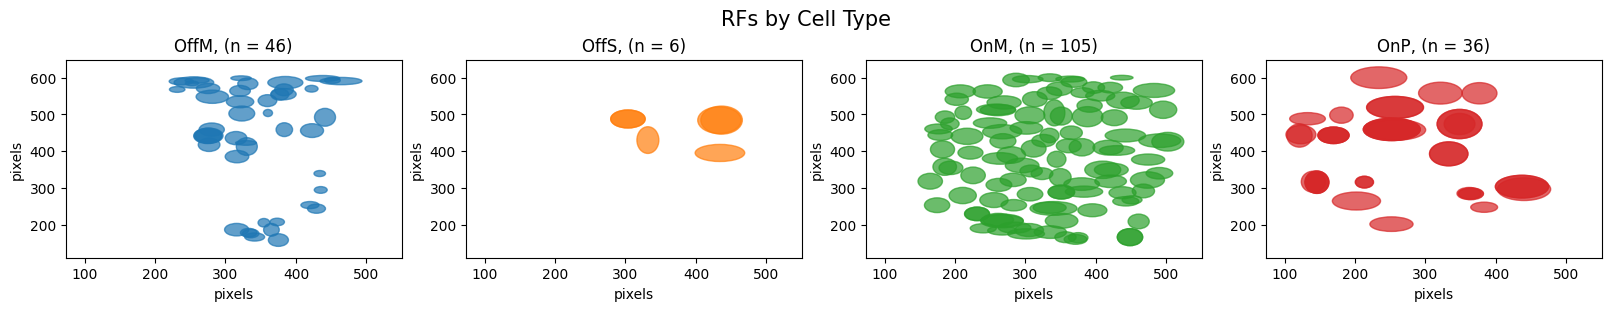

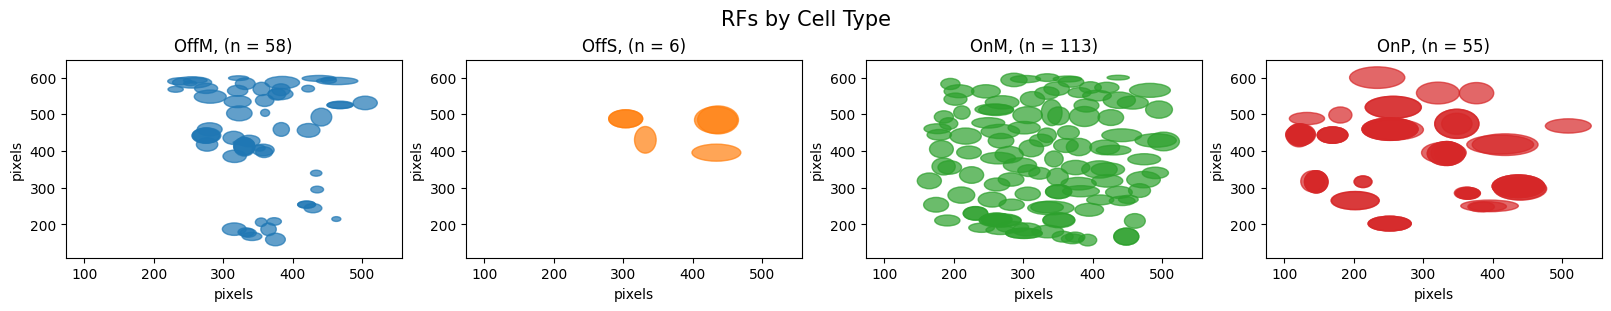

In [5]:
# Canonical types we'd like to look at (these mirror the labels in
# assets/cell_types.csv). The mapper is case-insensitive, so classification
# files using 'All/onP/', 'all/offp/', etc. will still resolve correctly.
requested_types = ['OnP', 'OffP', 'OnM', 'OffM', 'SBC', 'A1', 'BT', 'OnS', 'OffS']

# Re-map the existing cell_type column through the canonical list so any
# odd casing in the classification file collapses to the standard names.
def normalize(t):
    canon = ra.map_cell_type(t)        # case-insensitive lookup against cell_types.csv
    return canon if canon is not None else t

response_block.df_spike_times['cell_type'] = (
    response_block.df_spike_times['cell_type'].apply(normalize)
)

# Show what we ended up with
type_counts = response_block.df_spike_times['cell_type'].value_counts()
print('Cell-type counts (after normalization):')
print(type_counts.head(20))

# Keep only types that (a) are in our requested list and (b) actually exist
# with >=3 cells. Anything missing is silently skipped.
present_types = [t for t, n in type_counts.items() if n >= 3]
cell_types = ra.filter_available_types(requested_types, present_types)
skipped = [t for t in requested_types if t not in cell_types]
print(f'\nUsing cell_types: {cell_types}')
if skipped:
    print(f'Skipping (not present or <3 cells): {skipped}')

if len(cell_types) == 0:
    print('\nNo requested cell types found in this experiment — skipping RF plots.')
else:
    try:
        _ = pipeline.plot_rfs(cell_types=cell_types, minimum_n=3, b_zoom=True)
    except Exception as e:
        print(f'pipeline.plot_rfs skipped: {e}')
    try:
        _ = analysis_chunk.plot_rfs(
            cell_types=cell_types, minimum_n=3, b_zoom=True,
            typing_file=typing_file_name,
        )
    except Exception as e:
        print(f'analysis_chunk.plot_rfs skipped: {e}')

## 5. Inspect stimulus parameters

`stim_block.df_epochs` has one row per epoch with the params that varied (e.g. mean, variance, seed). `d_epoch_block_params` has the block-level params (preTime/stimTime/tailTime, etc.).

In [6]:
display(stim_block.df_epochs.head())

print('\nEpoch-block params:')
for k, v in stim_block.d_epoch_block_params.items():
    print(f'  {k}: {v}')

,epoch_index,currentBackgroundScale,backgroundIntensity,currentImageName,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,0.1,0.009608,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 17.0, 34.0, 50.0, 67.0, 83.0, 100.0, 116...","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32377
1,1,10.0,0.960779,00152,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 115....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32378
2,2,0.1,0.035755,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32379
3,3,10.0,3.575503,00459,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32380
4,4,0.1,0.020199,01151,20220823C,data035,Eye movement trajectory alt background rod,edu.washington.riekelab.turner.protocols.EyeMo...,"[0.0, 16.0, 33.0, 49.0, 66.0, 82.0, 99.0, 116....","{'D': 5.0, 'amp': 'Amp1', 'ndfs': '[]', 'xTraj...",20220823C/data035,30000.0,30000.0,0.0,22,315,866,41,32381



Epoch-block params:
  D: 5.0
  amp: Amp1
  preTime: 30000.0
  stimTime: 30000.0
  tailTime: 0.0
  patchMean: all
  randomSeed: 1.0
  sampleRate: 1000.0
  onlineAnalysis: none
  backgroundScale: [0.1, 10.0]
  apertureDiameter: 0.0
  numberOfAverages: 30


## 6. Pull spike times across cells

`get_spike_xarr` returns an xarray with dims `(cell_id, epoch)`, each entry an array of spike times in ms. Coords include `cell_type`, so you can `.sel`/`.where` by type. Filtering by `cell_types` keeps only EI-matched, typed cells.

In [7]:
if len(cell_types) == 0:
    print('No usable cell types — skipping spike xarray.')
    spike_times = None
else:
    spike_times = ra.get_spike_xarr(response_block, cell_types=cell_types, minimum_n=3)
    spike_counts = xr.apply_ufunc(len, spike_times, vectorize=True)

    print(f'Spike xarray shape: {dict(spike_times.sizes)}')
    print(f'Cell types present: {sorted(np.unique(spike_times.cell_type.values))}')

    # Baseline (pre-stim) counts per cell x epoch
    pre_time = stim_block.d_epoch_block_params['preTime']

    def baseline_count(arr, pre_time):
        return int(np.sum(np.asarray(arr) < pre_time))

    baseline_counts = xr.apply_ufunc(
        baseline_count, spike_times,
        kwargs={'pre_time': pre_time}, vectorize=True,
    )

    display(spike_counts)

Spike xarray shape: {'cell_id': 193, 'epoch': 30}
Cell types present: [np.str_('OffM'), np.str_('OffS'), np.str_('OnM'), np.str_('OnP')]


<xarray.DataArray (cell_id: 193, epoch: 30)> Size: 46kB
array([[2555, 1786, 1513, ..., 1485, 1305, 1487],
       [ 272, 1361,  472, ...,  440,  597,  533],
       [2425, 1793, 1303, ...,  429,  990,  582],
       ...,
       [   0,    3,    3, ...,   14,    7,    2],
       [ 227,  213,  117, ...,   68,  143,  126],
       [  33,   47,    0, ...,    0,    0,    0]], shape=(193, 30))
Coordinates:
  * cell_id    (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
    cell_type  (cell_id) <U4 3kB 'OnM' 'OnM' 'OnM' 'OnM' ... 'OffM' 'OnP' 'OnP'
    noise_id   (cell_id) int64 2kB 1 2 3 4 5 6 14 ... 570 571 575 588 599 600
  * epoch      (epoch) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29

## 7. Access STA + EI for a specific cell

After matching, you can look up any protocol cell's noise-chunk twin and grab its STA / EI / timecourse from `analysis_chunk`.

- `pipeline.match_dict[noise_cell_id] = protocol_cell_id` (noise → protocol)
- `analysis_chunk.d_EIs[noise_cell_id]` — electrical image
- `analysis_chunk.d_timecourses[noise_cell_id]` — RGB timecourses
- `analysis_chunk.d_ISIs[noise_cell_id]` — ISI distribution

Noise cell 1  <->  Protocol cell 1
EI shape: (512, 201)
Timecourse channels: ['red', 'green', 'blue']


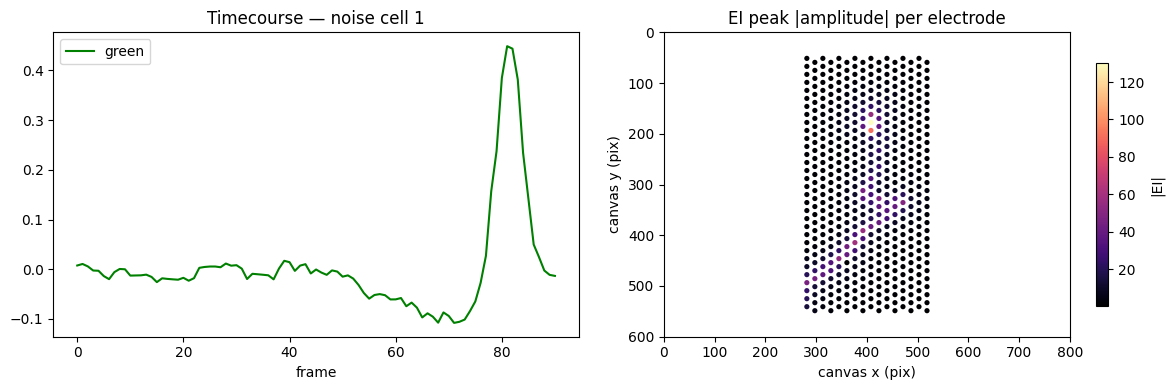

In [8]:
# Example: grab the first matched cell
noise_id, protocol_id = next(iter(pipeline.match_dict.items()))
print(f'Noise cell {noise_id}  <->  Protocol cell {protocol_id}')

ei = analysis_chunk.d_EIs[noise_id]
tc = analysis_chunk.d_timecourses[noise_id]

print(f'EI shape: {ei.shape}')
print(f'Timecourse channels: {list(tc.keys())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: spike-triggered timecourse(s).
axes[0].plot(tc['green'], color='g', label='green')
if not np.allclose(tc['red'], tc['green']):
    axes[0].plot(tc['red'], color='r', label='red')
    axes[0].plot(tc['blue'], color='b', label='blue')
axes[0].set_title(f'Timecourse — noise cell {noise_id}')
axes[0].set_xlabel('frame'); axes[0].legend()

# Right: per-electrode peak |EI| over time, plotted at the electrodes'
# canvas-pixel positions. The MEA-chip → canvas rotation is auto-resolved
# from the rig config (get_display_params_by_exp → mea_rotation_deg),
# so no rig-specific constants are needed in the notebook.
peak_abs = np.abs(ei).max(axis=-1)   # (n_electrodes,)
em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
canvas_w, canvas_h = analysis_chunk.canvas_size
sc = axes[1].scatter(em_canvas[:, 0], em_canvas[:, 1],
                     c=peak_abs, cmap='magma', s=14, edgecolors='none')
axes[1].set_xlim(0, canvas_w); axes[1].set_ylim(canvas_h, 0)
axes[1].set_aspect('equal')
axes[1].set_title(f'EI peak |amplitude| per electrode')
axes[1].set_xlabel('canvas x (pix)'); axes[1].set_ylabel('canvas y (pix)')
fig.colorbar(sc, ax=axes[1], shrink=0.8, label='|EI|')
plt.tight_layout()

## 8. Regenerate the stimulus (optional)

`ra.regen_stimulus(stim_block)` dispatches by protocol name to a per-protocol regen
function (registered in `retinanalysis.regen`). It returns an `xarray.Dataset` with
per-epoch trajectories + metadata, plus base images attached as
`ds.attrs['base_images']` when the protocol's source repo is findable under
`ra.PROTOCOL_REPOS_ROOT`.

If the repo isn't cloned locally, regen still returns trajectories/metadata and
just prints a heads-up — the rest of the notebook keeps working.

PROTOCOL_REPOS_ROOT: /Users/chrischen/Documents/GitHub
Registered regen protocols: ['edu.washington.riekelab.chris.protocols.MEAVariableMeanNoiseCone', 'edu.washington.riekelab.chris.protocols.VariableMeanSpatialNoise', 'edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']

regen_stimulus: using retinanalysis.regen.eye_movement_alt_bg.regen for edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground
[regen] found repo: /Users/chrischen/Documents/GitHub/turner-package
[regen] loaded 5 base image(s) from /Users/chrischen/Documents/GitHub/turner-package/resources/VHsubsample_20160105 (missing: none)

<xarray.Dataset> Size: 880kB
Dimensions:                 (epoch: 30, time: 1800)
Coordinates:
  * epoch                   (epoch) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29
    time_s                  (time) float64 14kB 0.0 0.01667 ... 29.97 29.98
Dimensions without coordinates: time
Data variables:
    xTraj_um                (e

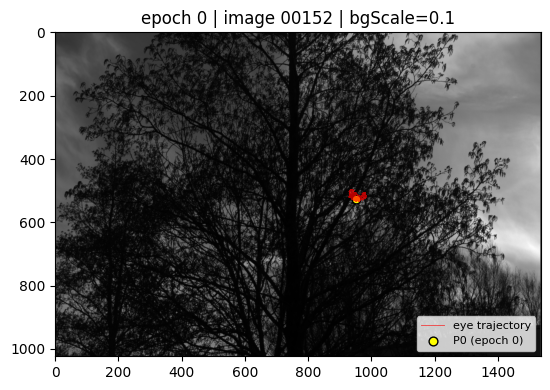

In [9]:
print(f'PROTOCOL_REPOS_ROOT: {ra.PROTOCOL_REPOS_ROOT or "(unset)"}')
print(f'Registered regen protocols: {ra.available_protocols()}\n')

stim_ds = ra.regen_stimulus(stim_block)

if stim_ds is None:
    print('\nNo regen function for this protocol — skipping.')
else:
    print()
    print(stim_ds)
    base_images = stim_ds.attrs.get('base_images', {})
    print(f'\nbase images available: {sorted(base_images.keys()) or "(none)"}')

    if base_images:
        # Show the first epoch's image with the saved P0 marked and the
        # eye-movement trajectory overlaid (in VH pixels, in image coords).
        e = 0
        img_name = str(stim_ds.image_name.values[e])
        img = base_images[img_name]
        p0x = float(stim_ds.currentP0_x_vhpix.values[e])
        p0y = float(stim_ds.currentP0_y_vhpix.values[e])

        um_per_vhpix = stim_ds.attrs['vh_um_per_pixel']
        traj_x_vhpix = stim_ds.xTraj_um.values[e] / um_per_vhpix
        traj_y_vhpix = stim_ds.yTraj_um.values[e] / um_per_vhpix

        fig, ax = plt.subplots(1, 1, figsize=(7, 4))
        ax.imshow(img, cmap='gray', origin='upper')
        ax.plot(p0x + traj_x_vhpix, p0y + traj_y_vhpix,
                color='red', lw=0.6, alpha=0.7, label='eye trajectory')
        ax.scatter([p0x], [p0y], color='yellow', s=40,
                   edgecolor='black', label=f'P0 (epoch {e})')
        ax.set_title(f'epoch {e} | image {img_name} | bgScale={stim_ds.currentBackgroundScale.values[e]:g}')
        ax.legend(loc='lower right', fontsize=8)
        plt.tight_layout()
        plt.show()

## 9. Render the displayed canvas + overlay mosaic and electrodes

`ra.render_displayed_canvas(stim_ds, epoch, frame=...)` returns a
`(canvas_h, canvas_w)` uint8 array — exactly what was on the monitor
that frame. Dispatches on `stim_ds.attrs['protocol_name']`:

- **`EyeMovementTrajectoryAlternatingBackground`**: VH image scaled by
  `vh_um_per_pixel / micronsPerPixel`, centered at canvas + `currentP0`
  offset, shifted by `xTraj_um`/`yTraj_um` at frame `k` (use `frame=None`
  for the pre-trajectory snapshot), background = `imageMean × bgScale`,
  clipped to `canvasSize`.
- **`VariableMeanSpatialNoise`**: stixel grid upscaled by `stixelSizePix`
  via `GL.NEAREST`, centered at canvas + per-frame jitter, background =
  `mean_sequence[frame]`, clipped to `canvasSize`.

The output drops straight into `plot_stim_with_mosaic(..., show_electrodes=True)`
with the default `frame_extent`. Electrodes are taken from
`vcd.get_electrode_map()` (MEA-chip µm) and converted via
`ra.electrode_positions_canvas_px(ac)`. The MEA-chip → canvas rotation
is resolved per rig from `get_display_params_by_exp(exp_name)`
(`mea_rotation_deg` key — Rig C = 90°, verified by minimum-distance
test on matched cells). Override per-call via `electrode_rotation_deg=`.

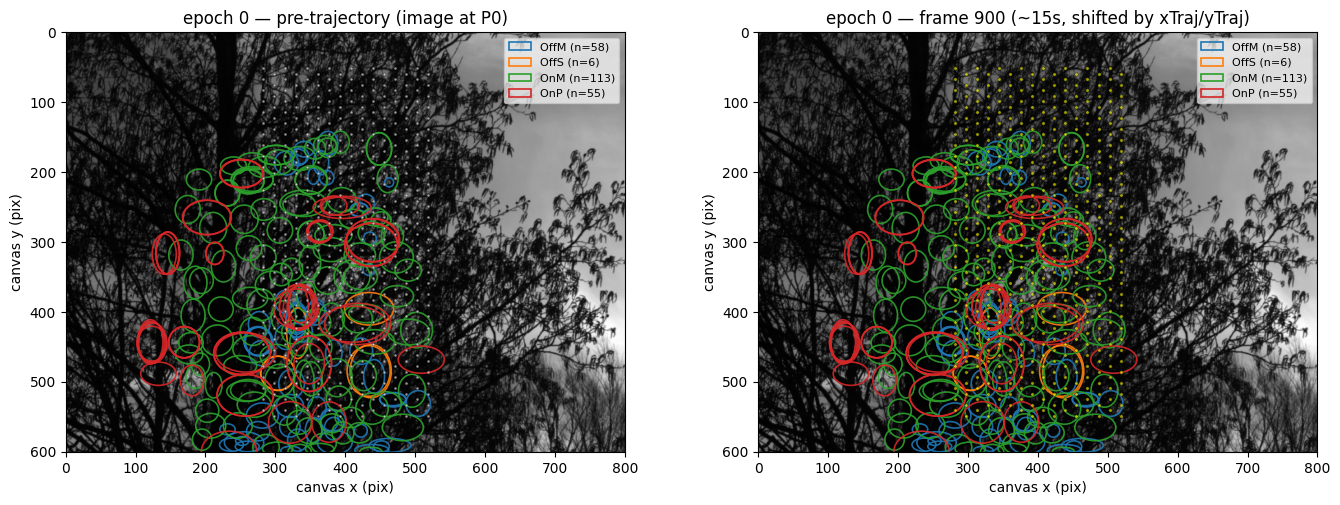

matched cells: n=232, nearest-electrode distance — median=7.8 px (30 µm), 90%ile=88.8 px


In [10]:
if stim_ds is not None and stim_ds.attrs.get('base_images'):
    # render_displayed_canvas → canvas-pixel buffer of exactly what the
    # monitor showed (image scaled by vh_um_per_pixel/microns_per_pixel,
    # offset by currentP0, shifted by eye trajectory at frame `k`,
    # background filled with backgroundIntensity, clipped to canvasSize).
    canvas_t0 = ra.render_displayed_canvas(stim_ds, epoch=0, frame=None)
    canvas_mid = ra.render_displayed_canvas(stim_ds, epoch=0, frame=900)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ra.plot_stim_with_mosaic(
        canvas_t0, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[0], show_electrodes=True,
        title='epoch 0 — pre-trajectory (image at P0)',
    )
    ra.plot_stim_with_mosaic(
        canvas_mid, analysis_chunk, cell_types=cell_types, minimum_n=3,
        ax=axes[1], show_electrodes=True,
        electrode_kwargs=dict(s=6, c='yellow', edgecolors='black', linewidths=0.4),
        title='epoch 0 — frame 900 (~15s, shifted by xTraj/yTraj)',
    )
    plt.tight_layout()
    plt.show()

    # Sanity check: matched cells should sit close to electrodes (each cell
    # is recorded by a nearby electrode). On a 30 µm hex array the typical
    # nearest-electrode distance is ~half the pitch (~15 µm).
    em_canvas = ra.electrode_positions_canvas_px(analysis_chunk)
    ppstix = analysis_chunk.pixels_per_stixel
    matched = (analysis_chunk.df_cell_params
               .query('typing_file_0 in @cell_types')['cell_id'].values)
    dists = []
    for cid in matched:
        rf = analysis_chunk.rf_params[cid]
        sta_xy = np.array([rf['center_x'] * ppstix, rf['center_y'] * ppstix])
        dists.append(np.linalg.norm(em_canvas - sta_xy, axis=1).min())
    dists = np.asarray(dists)
    print(f'matched cells: n={len(dists)}, '
          f'nearest-electrode distance — median={np.median(dists):.1f} px '
          f'({np.median(dists) * analysis_chunk.microns_per_pixel:.0f} µm), '
          f'90%ile={np.percentile(dists, 90):.1f} px')
else:
    print('No regen base images available — skipping displayed-canvas demo.')

## 10. Verify cell-type classification

The mosaic in section 4 is one check. Two more standard checks:

- **Mean temporal filter** — the green-channel STA timecourse averaged
  across cells of the same type should be tight and consistent
  (biphasic ON or OFF, peak at the same frame). Outliers drift apart.
- **Mean ISI distribution** — refractory period + post-spike timing.
  A coherent type has a tight refractory dip + similar bursting tail.

`ra.plot_cell_type_grid(analysis_chunk, cell_types, minimum_n=3)` stacks
all three panels per type into one figure.

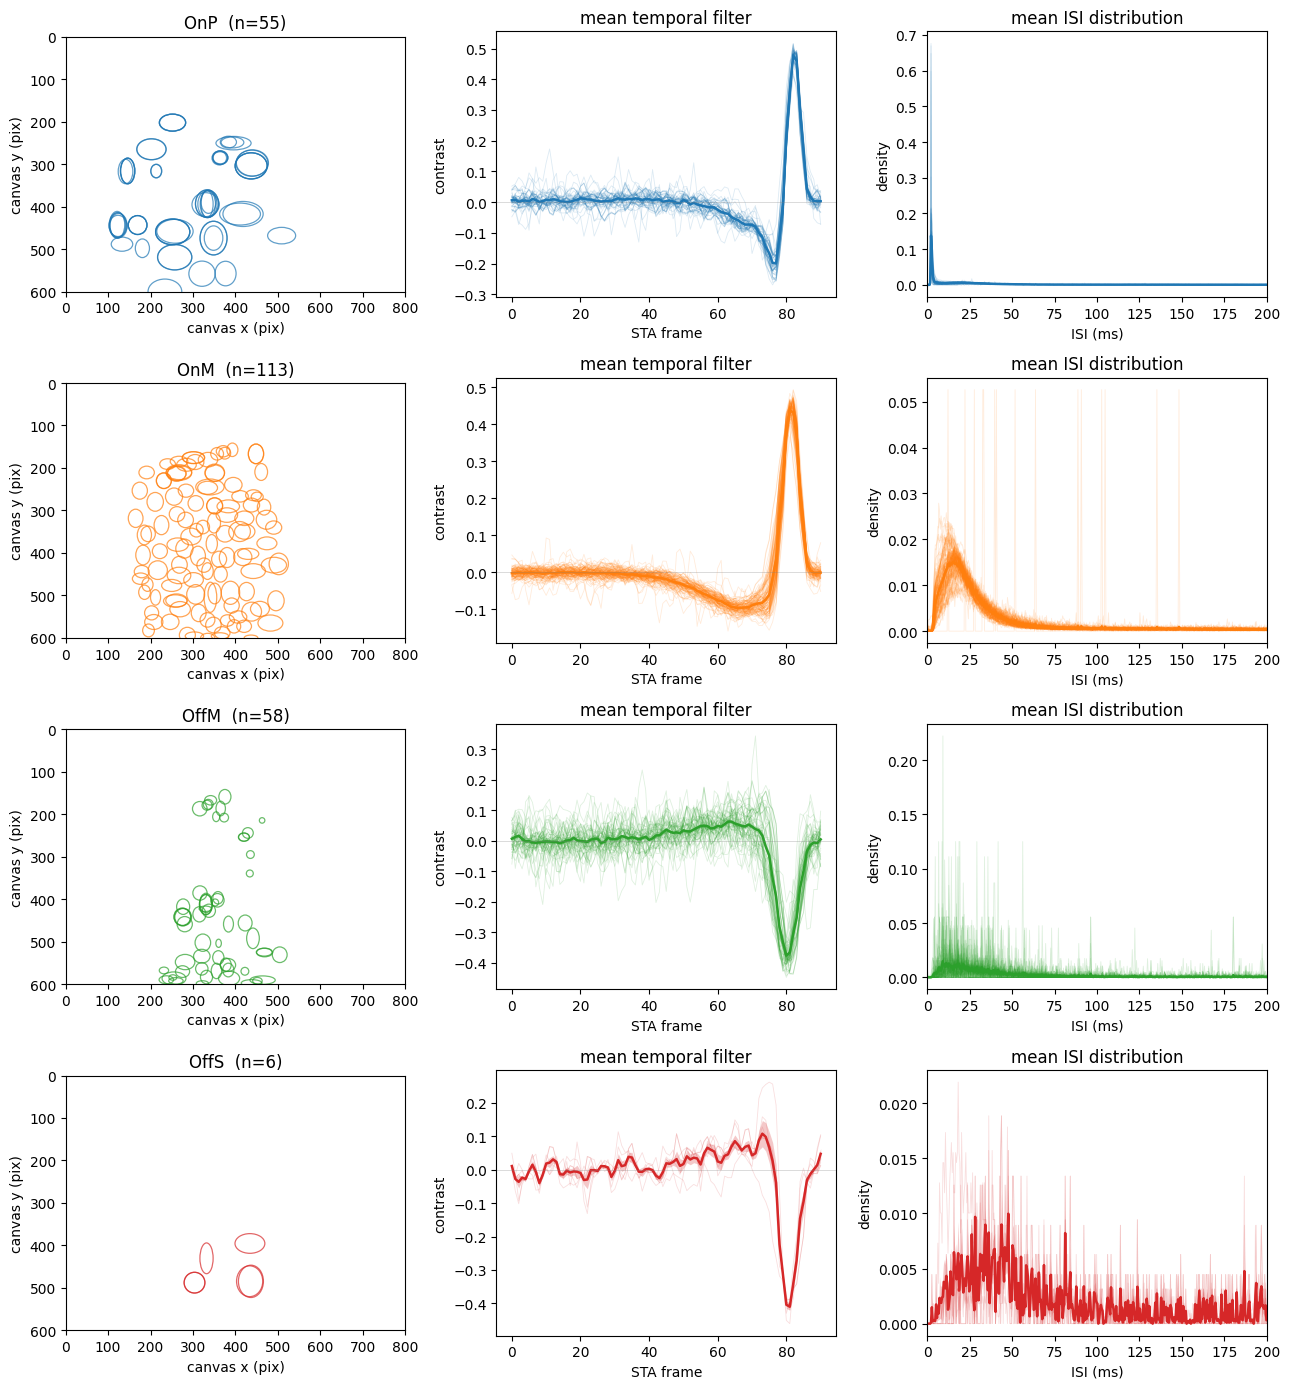

In [12]:
fig = ra.plot_cell_type_grid(analysis_chunk, cell_types, minimum_n=3)
plt.show()

## 11. Raster + PSTH for one cell type

`ra.plot_raster_with_psth(response_block, cell_type, ...)` draws one row
per `(cell, epoch)` pair (spikes as ticks) with the Gaussian-smoothed
PSTH at the bottom (mean ± SEM across rows). The PSTH uses the same
10 ms Gaussian-kernel convention as
[`spikeTimeToPSTH.m`](https://github.com/.../spatialIntegration) so
results are comparable across patch and MEA workflows.

Red dashed lines mark stim onset (`preTime`) and offset (`preTime + stimTime`).

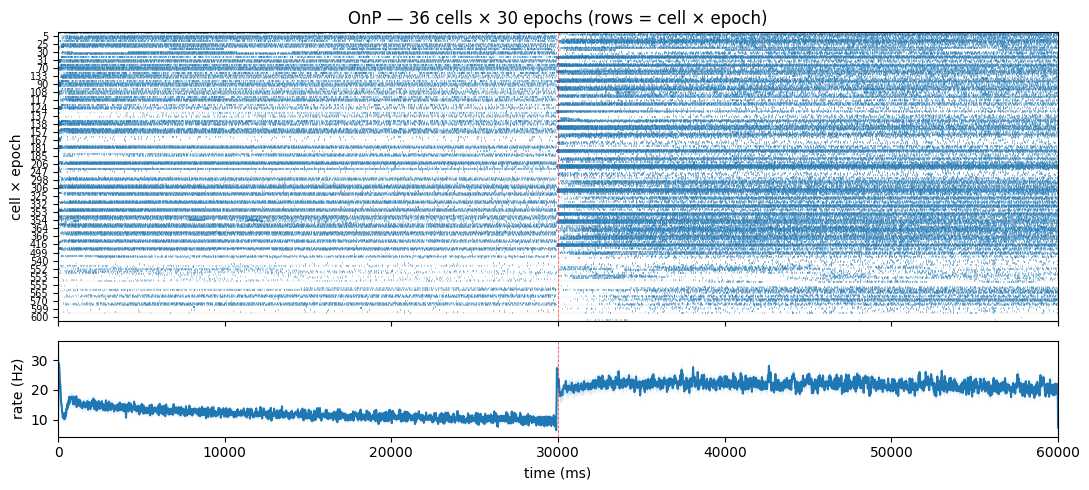

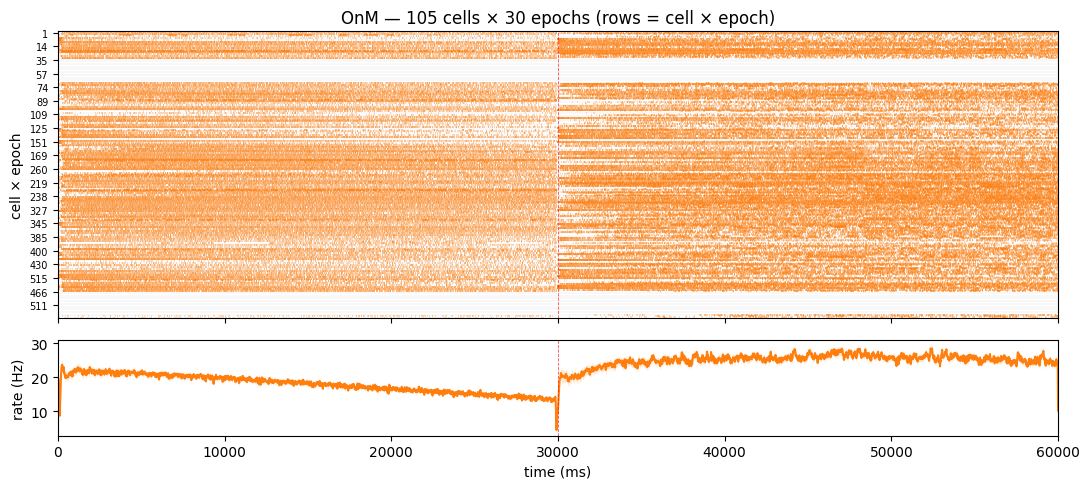

In [13]:
bp = stim_block.d_epoch_block_params
t_total_ms = bp['preTime'] + bp['stimTime'] + bp['tailTime']

# One panel per type (replace cell_types[:2] with the full list for all).
for ct in cell_types[:2]:
    fig, axes_rp = plt.subplots(2, 1, figsize=(11, 5),
                                 gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ra.plot_raster_with_psth(
        response_block, ct,
        t_end_ms=t_total_ms,
        pre_time_ms=bp['preTime'],
        stim_time_ms=bp['stimTime'],
        psth_sigma_ms=10.0,
        axes=axes_rp,
        raster_color=f'C{cell_types.index(ct)}',
    )
    plt.tight_layout()
    plt.show()

## 12. PSTH by condition

Protocol-specific analysis lives in
`retinanalysis.protocols.<protocol_module>` so each notebook stays lean.
For `EyeMovementTrajectoryAlternatingBackground` the natural split is
`currentBackgroundScale` (0.1 = dim background, 10 = bright background).

`analyze()` returns per-(cell-type × condition) PSTHs — one
`(n_cells, n_bins)` matrix each. `plot_psth_by_condition()` makes one
panel per type with conditions overlaid (mean ± SEM across cells).

In [ ]:
from retinanalysis.protocols import eye_movement_alt_bg as em

# Each image is shown twice (once per backgroundScale) — average across
# images would wash out per-image response structure, so we group by
# (image, backgroundScale) and plot one panel per image with bg overlaid.
results = em.analyze(
    pipeline,
    cell_types=cell_types,
    condition_keys=['currentImageName', 'currentBackgroundScale'],
    psth_sigma_ms=10.0,
    minimum_n=3,
)
print(f'condition_keys: {results["condition_keys"]}')
print(f'n_conditions: {len(results["conditions"])}  '
      f'(= n_images × n_bg_scales)')
print(f'types passing minimum_n: {results["cell_types"]}')

em.plot_psth_by_condition(results)  # auto-grids when len(keys) == 2
plt.show()

## 13. Per-experiment MEA→canvas calibration

The chip is physically remounted between recording days, so the geometry that maps electrode µm onto the display canvas is a *per-experiment* constant. We derive it empirically: for each cell, pair its AP-initiation EI electrode (a soma proxy) with its STA center on the canvas, then fit a 2D similarity transform (rotation + uniform scale + translation) by Procrustes/SVD. Robust trimming rejects outlier pairs (cells with bad STAs or off-array EIs).

Calibrations are stored at `<repo>/rig_calibrations/<exp_name>.json`. The overlay helper looks one up automatically — pass `recompute_alignment=True` to override with a fresh fit just for this chunk, or `save_recomputed=True` to also persist the new fit.

Convergence: residual is reported in µm. ~one electrode pitch (60 µm) on a well-fit chunk; bigger residuals point to noisy STA centers or many off-array EI peaks.

In [ ]:
from retinanalysis.utils import rig_calibration as rc

# 13a. Empirical array geometry (no hardcoded "60 µm pitch / 512 electrodes").
# Derived from analysis_chunk.vcd.get_electrode_map() so downstream filters
# scale with whichever array was actually used.
geom = ra.electrode_geometry(analysis_chunk)
print(f'electrode array: {geom["n_electrodes"]} channels, '
      f'pitch={geom["pitch_um"]:.1f} µm, '
      f'footprint {geom["width_um"]:.0f} x {geom["height_um"]:.0f} µm')

# 13b. Try to load an existing calibration for this experiment.
calib = rc.load_rig_calibration(analysis_chunk.exp_name)
if calib is None:
    print(f'No saved calibration for {analysis_chunk.exp_name}. Fitting fresh.')
    calib = rc.fit_calibration_for_chunk(analysis_chunk, verbose=True)
    path = rc.save_rig_calibration(calib)
    print(f'Saved → {path}')
else:
    print(f'Loaded calibration for {calib.exp_name} '
          f'(rig {calib.rig_id}, fit from {calib.n_recordings} recording(s))')

print(f'  rotation = {calib.rotation_deg:.2f}°')
print(f'  scale    = {calib.scale_px_per_um:.4f} px/µm   '
      f'(1/scale = {1.0/calib.scale_px_per_um:.3f} µm/px, rig-config = {analysis_chunk.microns_per_pixel:.3f})')
print(f'  trans    = ({calib.tx_px:.1f}, {calib.ty_px:.1f}) px   '
      f'(canvas center = {analysis_chunk.canvas_size[0]/2:.0f}, {analysis_chunk.canvas_size[1]/2:.0f})')
print(f'  residual = {calib.residual_um_rms:.1f} µm '
      f'({calib.residual_um_rms/geom["pitch_um"]:.2f} × pitch) '
      f'over {calib.n_cells} inlier cells')

# 13c. Visual comparison: overlay electrodes via the calibration vs the
# old centered-chip + rig-rotation geometry. Both panels zoom to the chip
# footprint and drop cells whose RFs are too far from any electrode — the
# default mosaic includes many noisy STAs whose centers land off-array,
# making the cell coverage *look* much larger than the recording area.
# Thresholds are in multiples of the empirical electrode pitch so the
# same call works across array types.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ra.plot_stim_with_mosaic(
    np.full((int(analysis_chunk.canvas_size[1]), int(analysis_chunk.canvas_size[0])), 0.85),
    analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[0], show_electrodes=True,
    use_calibration=False,
    restrict_to_array_pitch=2.0,   # drop RFs > 2 electrode pitches off-array
    zoom_to_array=True,
    zoom_pad_pitch=2.0,
    title='electrode overlay: geometric (rig-config 90°)',
)
ra.plot_stim_with_mosaic(
    np.full((int(analysis_chunk.canvas_size[1]), int(analysis_chunk.canvas_size[0])), 0.85),
    analysis_chunk, cell_types=cell_types, minimum_n=3,
    ax=axes[1], show_electrodes=True,
    use_calibration=True,
    restrict_to_array_pitch=2.0,
    zoom_to_array=True,
    zoom_pad_pitch=2.0,
    title='electrode overlay: calibrated (EI↔STA fit)',
)
plt.tight_layout()
plt.show()

## 14. Per-cell QC inside the protocol

A cell can pass classification on the noise chunk and still misbehave inside a downstream protocol — drift off, drop out for runs of trials, or barely fire. `protocol_qc.block_qc_metrics` returns a per-cell metrics DataFrame; `filter_cells_by_qc` adds a boolean `passes` column with sensible defaults (override any threshold per-call). Metrics computed: mean spike count, CV, Fano, silent-trial fraction, longest silent-run, drift score, and (off by default) split-half PSTH reliability.

The Fano threshold is **disabled by default** because Fano scales with mean count — a reliable cell firing hundreds of spikes per 30 s trial routinely has Fano ≈ 40-100. Use CV for cross-protocol filtering; the Fano value is still reported as a diagnostic.

In [ ]:
from retinanalysis.utils.protocol_qc import (
    block_qc_metrics, filter_cells_by_qc, QCThresholds,
)

t_total_ms = (
    response_block.d_timing['pre_time_ms']
    + response_block.d_timing['stim_time_ms']
    + response_block.d_timing['tail_time_ms']
)
qc_metrics = block_qc_metrics(response_block, t_start_ms=0, t_end_ms=t_total_ms)
qc = filter_cells_by_qc(qc_metrics)         # uses QCThresholds() defaults

n_pass = int(qc.passes.sum())
print(f'Total cells: {len(qc)},  Passing QC: {n_pass} ({100*n_pass/len(qc):.1f}%)')
print('\nPass rate by cell type:')
for ct, sub in qc.groupby('cell_type'):
    print(f'  {ct:<12}  {sub.passes.sum():>4} / {len(sub):>4}  ({100*sub.passes.mean():.0f}%)')

# Cells failing the dropout check (silent_run_max > 10) are the most
# interesting failures — peek at a few:
dropouts = qc.query('silent_run_max > 10').sort_values('silent_run_max', ascending=False)
print(f'\nCells with long silent runs ({len(dropouts)}):')
display(dropouts[['cell_id', 'cell_type', 'n_epochs',
                  'mean_count', 'silent_trial_frac',
                  'silent_run_max', 'drift_score', 'passes']].head())

## 15. Per-cell PNG archive (mosaic + raster + PSTH)

Scrolling through every cell inline is painful past ~30 cells. `save_per_cell_plots` writes one `.png` per cell to a structured folder tree under `OUTPUT_DIR/cell_plots/<exp>/<chunk>/<protocol>/cells/<celltype>/cell_<id>.png`, plus a `mosaic_overview.png` and an `index.csv` summarizing what was rendered. Pass `qc_pass_only=qc` to skip cells that failed QC. Reruns are incremental — already-rendered PNGs are skipped unless you pass `overwrite=True`.

In [ ]:
from retinanalysis.utils.cell_plot_archive import save_per_cell_plots

# Save a small demo set (one per main type) so this cell runs fast in the
# notebook. Drop `cell_ids=` to render the full main-type archive.
demo_ids = []
for ct in ['OnP', 'OffP', 'OnM', 'OffM']:
    sub = qc[(qc.cell_type == ct) & qc.passes].head(1)
    demo_ids.extend(sub.cell_id.astype(int).tolist())
print(f'Rendering {len(demo_ids)} demo cells: {demo_ids}')

# Passing stim_block enables condition-coloring: raster rows + PSTH lines
# are split by `currentBackgroundScale` (auto-detected for this protocol).
# Already-rendered cells are skipped — re-running this cell is incremental.
index = save_per_cell_plots(
    analysis_chunk,
    response_block,
    stim_block=stim_block,
    cell_ids=demo_ids,
    qc_pass_only=qc,
    ndf=float(stim_block.df_epochs['epoch_parameters'].iloc[0].get('NDF', float('nan'))),
    overwrite=False,
    verbose=True,
)
display(index)

## 16. Archive the picked date (single date)

§15 above only renders a handful of demo cells. To write the **full** per-cell PNG archive for the date selected in §2 — `mosaic.png`, `index.csv`, `cell_match.csv`, and `cells/<celltype>/cell_<id>_{raster,psth}.png` for every QC-passing cell — call `ra.analyze_experiment(exp_name, datafile_name)`. This is the same driver §17 uses internally per date in its batch loop; running it here builds the archive for *just* the one date you've been inspecting, before committing to the full batch.

In [ ]:
# Full archive for the date picked in §2. Uses the same exp_name and
# datafile_name we've been working with through §3–§13. overwrite=True
# regenerates every PNG; flip to False to skip already-rendered cells.
result = ra.analyze_experiment(
    exp_name,
    datafile_name=datafile_name,
    overwrite=True,
    fit_calibration=False,
    n_jobs=-1,
    verbose=True,
)
print(f'\nDone: {result["exp_name"]} / {result["datafile_name"]} — '
      f'{result["n_cells_passed_qc"]}/{result["n_cells_total"]} cells passed QC')
print(f'  output_dir: {result["output_dir"]}')

## 17. Run the archive for one or many dates (standalone)

This section is **self-contained** — run cell 1 (imports), then jump straight here. `ra.analyze_experiments` packages every step the earlier cells did manually into a single call per date: ss_version + typing file + datafile auto-detect, pipeline build, optional rig calibration, type normalization, QC, composite `mosaic.png` (with temporal-filter + ISI rows), and per-cell `cell_<id>_raster.png` + `cell_<id>_psth.png`.

Runs are incremental (existing PNGs are skipped) and parallel (`n_jobs=-1` uses every CPU core). Use `on_error='log'` so a bad date is recorded in the summary instead of aborting the batch.

In [ ]:
# Section 17 is SELF-CONTAINED — you only need cell 1 (imports) to run it.
# It will query the protocol registry on its own and dispatch the archive
# pipeline over every experiment found, in parallel.

import os
import pandas as pd

# ---- USER INPUT --------------------------------------------------------
# Yes/no: should we (re)save figures for every cell?
#   True  → render and OVERWRITE all PNGs (use this to refresh stale plots)
#   False → skip the archive step entirely (just list the batch and stop)
SAVE_FIGURES = True
# ------------------------------------------------------------------------

PROTOCOL_SEARCH = 'AlternatingBackground'   # substring matched against protocol names

# Build the date list from the protocol registry, keeping only experiments
# whose sort output is present on disk.
_exp_search = ra.get_datasets_from_protocol_names(PROTOCOL_SEARCH)
_available = set(os.listdir(ra.ANALYSIS_DIR))
_exp_search = _exp_search[_exp_search['exp_name'].isin(_available)]
batch_dates = _exp_search['exp_name'].unique().tolist()

# Subset variants — uncomment / adapt as needed:
# batch_dates = ['20220823C', '20221123C', '20230502C']                                            # hand-pick
# batch_dates = _exp_search.query("exp_name >= '20230101C'")['exp_name'].unique().tolist()        # by date
# batch_dates = _exp_search.query('NDF == 2.0')['exp_name'].unique().tolist()                     # by NDF

print(f'Batch run over {len(batch_dates)} dates: {batch_dates}')
print(f'SAVE_FIGURES = {SAVE_FIGURES}  '
      f'({"overwrite all PNGs" if SAVE_FIGURES else "skip archive step"})')

if not SAVE_FIGURES:
    print('SAVE_FIGURES is False — not calling ra.analyze_experiments. '
          'Set SAVE_FIGURES = True above to (re)render PNGs.')
else:
    results = ra.analyze_experiments(
        batch_dates,
        protocol_search=PROTOCOL_SEARCH,    # resolves datafile per date
        fit_calibration=False,              # True on first pass to seed calibrations
        overwrite=True,                     # resave every PNG (driven by SAVE_FIGURES)
        n_jobs=-1,                          # all CPU cores for per-cell rendering
        on_error='log',                     # keep going past per-date failures
        verbose=True,
    )

    summary = pd.DataFrame([
        {k: r.get(k) for k in
         ['exp_name', 'datafile_name', 'chunk_name',
          'n_cells_total', 'n_cells_passed_qc', 'ndf', 'error']}
        for r in results
    ])
    display(summary)


## 18. Visual QC (optional) — click through each cell, tag good/bad

**This step is optional.** By default, every cell that passed the automated protocol QC in section 17 is treated as "good" for downstream population analysis — those are exactly the cells with rendered PNGs / a row in `index.csv`.

Use the visual-QC GUI only when you want to **further restrict** that set by eyeballing each cell. `ra.browse_cells_qc(exp_name)` opens an in-notebook widget that pages through cells, showing **raster on the left, PSTH on the right**, with `Good` / `Bad` / `Prev` / `Next` buttons. Each click writes a row to `<OUTPUT_DIR>/<exp>/<protocol>/visual_qc.csv` so the session is resumable.

Downstream selection:

```python
# Always returns the set to feed into population analysis.
cells = ra.select_good_cells()
# 'auto' (default): per-experiment, use visual_qc.csv if it exists,
#                   otherwise fall back to all QC-passers.
# 'ignore':         never read visual_qc.csv (use QC-passers everywhere).
# 'require':        error if any experiment is missing visual_qc.csv.
```

Requirements: `ipywidgets` (already in the `retinanalysis` kernel).

In [ ]:
# --- DEFAULT: no manual review needed --------------------------------------
# `select_good_cells` returns the set to feed into population analysis.
# When no visual_qc.csv has been saved yet, it returns every QC-passing
# cell across every experiment with a rendered archive on disk.
cells = ra.select_good_cells()
print(f'{len(cells)} cells available for population analysis '
      f'(across {cells["exp_name"].nunique()} experiments)')
display(cells.head())

# --- OPTIONAL: launch the per-cell GUI to further restrict ----------------
# Uncomment to open the widget for one experiment. Each click writes to
# <OUTPUT_DIR>/<exp>/eye_movement_alt_bg/visual_qc.csv. After tagging,
# re-run `select_good_cells()` to pick up the new filter.
#
# qc_exp = exp_name if 'exp_name' in dir() else '20220823C'
# ra.browse_cells_qc(qc_exp)

## 19. Cell-match table & EI stats (persisted across sessions)

`analyze_experiment` (§16 / §17) writes one `cell_match.csv` per experiment alongside `index.csv`. Each row links a noise-chunk cell to its protocol-side match and snapshots the EI summary stats so future sessions can pull this without rebuilding the pipeline:

| column | meaning |
|---|---|
| `protocol_cell_id` ↔ `noise_cell_id` | the EI-based match (was only in `pipeline.match_dict` before) |
| `ei_corr` | best EI correlation that won the match |
| `ei_peak_amp` | max \|EI\| across electrodes/samples |
| `ei_peak_electrode`, `ei_peak_x_um`, `ei_peak_y_um` | soma electrode + chip-µm location |
| `ei_peak_sample` | sample idx of the peak (spike-timing offset within the EI window) |
| `ei_n_active_electrodes` | electrodes whose peak \|EI\| ≥ 20% of the global peak (footprint size) |
| `ei_spread_um` | RMS distance of active electrodes from the peak — footprint width |
| `ei_snr` | peak / median(inactive-electrode peaks) — coarse SNR |

Load with `ra.load_cell_match()`. For population analyses, join to `ra.select_good_cells()` on `(exp_name, protocol_cell_id ↔ cell_id)` to attach EI stats to the QC-passed pool.

In [ ]:
cm = ra.load_cell_match()
print(f'cell_match: {len(cm)} cells from {cm["exp_name"].nunique()} experiments\n')

# Per-(experiment, type) summary medians — quick way to spot bad chunks.
agg = (cm.groupby(['exp_name', 'cell_type'])
         [['ei_corr', 'ei_peak_amp', 'ei_n_active_electrodes',
           'ei_spread_um', 'ei_snr']]
         .median()
         .round(2))
display(agg)

# Distributions across all cells of the main types.
import matplotlib.pyplot as plt
main_types = [t for t in ['OnP', 'OffP', 'OnM', 'OffM']
              if t in cm['cell_type'].unique()]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ct in main_types:
    sub = cm[cm.cell_type == ct]
    axes[0].hist(sub['ei_corr'],   bins=40, histtype='step', label=ct)
    axes[1].hist(sub['ei_snr'],    bins=40, histtype='step', label=ct,
                 range=(0, 500))
    axes[2].hist(sub['ei_spread_um'], bins=40, histtype='step', label=ct)
axes[0].set_xlabel('EI correlation'); axes[0].set_title('match quality')
axes[1].set_xlabel('EI SNR');         axes[1].set_title('signal strength')
axes[2].set_xlabel('EI spread (µm)'); axes[2].set_title('footprint size')
for ax in axes:
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

# Population-ready join: QC-passed cells annotated with their EI stats.
cells = ra.select_good_cells().rename(columns={'cell_id': 'protocol_cell_id'})
pop = cells.merge(cm, on=['exp_name', 'protocol_cell_id', 'cell_type'],
                   how='left', suffixes=('', '_cm'))
print(f'\npopulation pool: {len(pop)} cells '
      f"(matched to EI stats: {pop['ei_corr'].notna().sum()})")
display(pop.head())